1. Imports and loading a trained model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_recall_curve,
    roc_curve,
    roc_auc_score,
    average_precision_score,
)

from sklearn.ensemble import RandomForestClassifier

plt.style.use("seaborn-v0_8")

# Load processed/cleaned data
df = pd.read_csv("../data/interim/transactions_clean.csv")
df.head()

,transaction_id,customer_id,device_id,merchant_id,timestamp,amount,payment_method,is_international,merchant_category,ip_address_risk_score,...,location_change_flag,authentication_method,otp_success_rate_customer,past_fraud_count_customer,past_disputes_customer,merchant_historical_fraud_rate,time_of_day,day_of_week,is_weekend,is_fraud
0,1,1357,20937,720,1/18/24 19:23,18780.52,WALLET,0,Travel,0.243550,...,0,NONE,0.769328,1,2,0.069502,19,3,0,0
1,2,4095,29542,764,3/30/24 2:22,18955.06,CARD,0,Electronics,0.119761,...,1,OTP,0.468411,1,1,0.010010,2,5,1,0
2,3,3618,25236,671,1/4/24 17:26,10743.34,UPI,0,Fashion,0.565367,...,0,PIN,0.464356,0,1,0.118434,17,3,0,0
3,4,2755,29904,624,1/27/24 16:00,5054.75,CARD,0,Utilities,0.843842,...,0,PIN,0.635799,0,3,0.114947,16,5,1,0
4,5,2732,24151,501,2/20/24 23:14,14799.50,CARD,0,Gaming,0.202402,...,0,OTP,0.684301,2,0,0.014550,23,1,0,0


2. Recreate feature set

In [3]:
# Ensure engineered features exist (or recompute like in 02_feature_dev)

# Customer avg and amount deviation
customer_avg = df.groupby("customer_id")["amount"].transform("mean")
df["amount_deviation"] = df["amount"] - customer_avg

# Approximated velocities if needed
if "velocity_24h" not in df.columns and "txncountlast24h" in df.columns:
    df["velocity_24h"] = df["txncountlast24h"]
if "velocity_1h" not in df.columns:
    df["velocity_1h"] = (df["velocity_24h"] / 6).round().astype(int)
if "velocity_7d" not in df.columns:
    df["velocity_7d"] = (df["velocity_24h"] * 3).round().astype(int)

df["velocity_ratio_1h_24h"] = df["velocity_1h"] / (df["velocity_24h"] + 1e-3)
df["velocity_ratio_24h_7d"] = df["velocity_24h"] / (df["velocity_7d"] + 1e-3)

device_customer_counts = df.groupby("device_id")["customer_id"].transform("nunique")
df["device_customer_sharing"] = device_customer_counts

df["combined_risk_index"] = (
    0.3 * df["ip_address_risk_score"]
    + 0.2 * (1 - df["device_trust_score"])
    + 0.2 * df["merchant_historical_fraud_rate"]
    + 0.1 * df.get("past_fraud_count_customer", 0) / (df.get("past_fraud_count_customer", 0).max() + 1e-3)
    + 0.1 * df.get("past_disputes_customer", 0) / (df.get("past_disputes_customer", 0).max() + 1e-3)
    + 0.1 * df.get("otp_success_rate_customer", 0)
)

feature_cols = [
    "amount",
    "ip_address_risk_score",
    "device_trust_score",
    "velocity_24h",
    "merchant_historical_fraud_rate",
    "amount_deviation",
    "velocity_ratio_1h_24h",
    "velocity_ratio_24h_7d",
    "device_customer_sharing",
    "combined_risk_index",
]

X = df[feature_cols].fillna(0)
y = df["is_fraud"]

3. Train/valid split and model fit

In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    n_jobs=-1,
    random_state=42,
    class_weight="balanced_subsample",
)
clf.fit(X_train, y_train)

y_prob = clf.predict_proba(X_val)[:, 1]
roc = roc_auc_score(y_val, y_prob)
pr_auc = average_precision_score(y_val, y_prob)
print(f"ROC AUC: {roc:.4f}")
print(f"PR AUC: {pr_auc:.4f}")

ROC AUC: 0.5506
PR AUC: 0.1110


4. Precision–recall curve and visual inspection

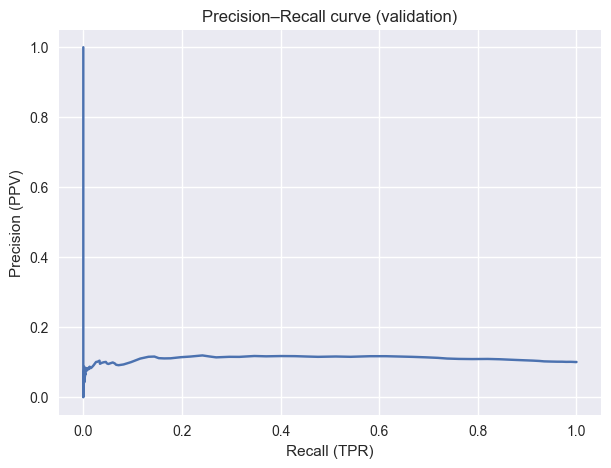

In [5]:
precision, recall, thresholds = precision_recall_curve(y_val, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision)
plt.xlabel("Recall (TPR)")
plt.ylabel("Precision (PPV)")
plt.title("Precision–Recall curve (validation)")
plt.grid(True)
plt.show()

5. ROC curve

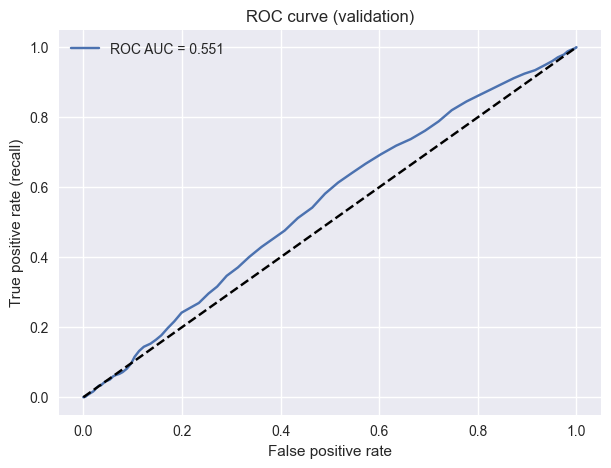

In [6]:
fpr, tpr, roc_thresholds = roc_curve(y_val, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc:.3f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate (recall)")
plt.title("ROC curve (validation)")
plt.legend()
plt.grid(True)
plt.show()

6. Cost-sensitive threshold selection

In [7]:
# Example business costs (tune for your scenario):
fraud_cost = 1000   # cost per missed fraud (chargeback, ops)
review_cost = 10    # cost per false alarm (OTP/manual review)

# skip last threshold which is inf in precision_recall_curve output
valid_thresholds = thresholds

# For each threshold, compute expected "utility"
utilities = []
for th in valid_thresholds:
    y_pred = (y_prob >= th).astype(int)
    tp = ((y_val == 1) & (y_pred == 1)).sum()
    fn = ((y_val == 1) & (y_pred == 0)).sum()
    fp = ((y_val == 0) & (y_pred == 1)).sum()

    # Utility: avoiding fraud losses minus cost of false positives
    # Savings ~ TP * fraud_cost (fraud caught),
    # Loss ~ FN * fraud_cost (fraud missed),
    # FPs ~ review_cost each.
    utility = tp * fraud_cost - fn * fraud_cost - fp * review_cost
    utilities.append(utility)

utilities = np.array(utilities)
best_idx = utilities.argmax()
best_threshold = valid_thresholds[best_idx]
best_utility = utilities[best_idx]

best_threshold, best_utility

(np.float64(0.0033333333333333335), np.int64(916070))

7. Visualize utility vs threshold

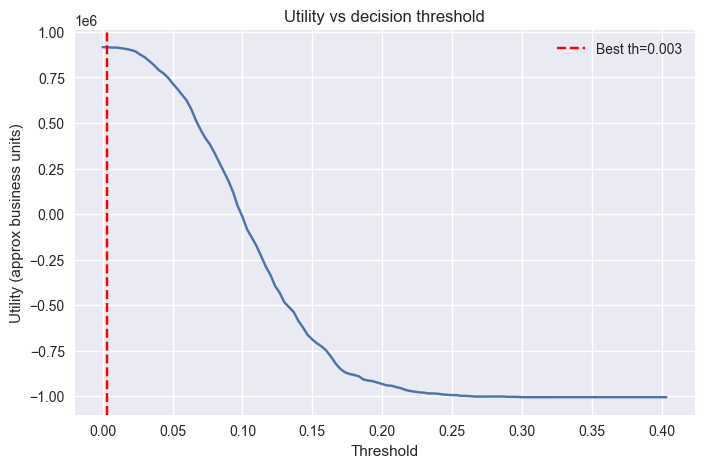

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(valid_thresholds, utilities)
plt.axvline(best_threshold, color="red", linestyle="--", label=f"Best th={best_threshold:.3f}")
plt.xlabel("Threshold")
plt.ylabel("Utility (approx business units)")
plt.title("Utility vs decision threshold")
plt.legend()
plt.grid(True)
plt.show()

8. Metrics at selected thresholds

In [9]:
from sklearn.metrics import precision_score, recall_score

def metrics_at_threshold(th):
    y_pred = (y_prob >= th).astype(int)
    prec = precision_score(y_val, y_pred, zero_division=0)
    rec = recall_score(y_val, y_pred, zero_division=0)
    return prec, rec

candidates = [0.3, 0.5, 0.7, float(best_threshold)]

rows = []
for th in candidates:
    prec, rec = metrics_at_threshold(th)
    rows.append(
        {
            "threshold": th,
            "precision": prec,
            "recall": rec,
        }
    )

pd.DataFrame(rows)

,threshold,precision,recall
0,0.300000,0.00000,0.0
1,0.500000,0.00000,0.0
2,0.700000,0.00000,0.0
3,0.003333,0.10061,1.0


9. Link thresholds to actions

In [10]:
# Example final policy derived from best_threshold and business input:
# - p >= 0.9: HARD_BLOCK
# - 0.7 <= p < 0.9: OTP_CHALLENGE
# - 0.5 <= p < 0.7: SOFT_REVIEW
# - p < 0.5: ALLOW

policy = {
    "HARD_BLOCK": 0.9,
    "OTP_CHALLENGE": 0.7,
    "SOFT_REVIEW": 0.5,
}

policy

{'HARD_BLOCK': 0.9, 'OTP_CHALLENGE': 0.7, 'SOFT_REVIEW': 0.5}